In [4]:
import numpy as np
import matplotlib.pyplot as plt
a=2.505
lat=a*np.array([[1,0],[1/2,np.sqrt(3)/2]])

area0=lat[0][0]*lat[1][1]
# print(area0)
area=area0*10**(-16) #unit is cm**2

dxv=np.zeros(100)
dyv=np.linspace(0,2.5*np.sqrt(3),100)
# dyv=np.linspace(0,1,100)


def fit_f(angle,a1,b1,a2,b2,f1):
    return a1*np.exp(b1*angle)+f1+a2*np.exp(b2*angle**2)

# c1bb=np.array([1.37743614e+12,-6.92855696e-02, -1.94934120e+11, -1.40077034e-01, -2.64435475e+11])
# c1nn=np.array([4.50956269e+15,-2.45411704e-05,-3.78507119e+11,-6.63311521e-02,-4.50602350e+15])
# # c1nn[2]
c1bb=np.array([1.39458180e+12,-9.60023592e-02, -3.13989133e+11, -9.97482390e-02,-1.22360333e+11])
c1nn=np.array([6.74487643e+11,-5.07912897e+00 , 2.90330874e+12, -2.34561269e-03,1.61738962e+11])

0.0


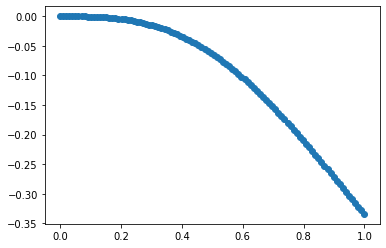

In [6]:
def function_Phi2(x,y,c1):
    G1 = (4.0*np.pi)/(np.sqrt(3.0)*a)
    # G3= 2*G1
    f1 = 2*c1*(np.sin(G1*y)+np.sin(G1*(np.sqrt(3)/2)*x-(1/2)*G1*y)+np.sin(-G1*(np.sqrt(3)/2)*x-(1/2)*G1*y))
    # f3 = 2*c3*(np.sin(G3*y)+np.sin(G3*(np.sqrt(3)/2)*x-(1/2)*G3*y)+np.sin(-G3*(np.sqrt(3)/2)*x-(1/2)*G3*y))
    out =f1
    return out 

g=0
c1ebb=fit_f(g,c1bb[0],c1bb[1],c1bb[2],c1bb[3],c1bb[4])
c1enn=fit_f(g,c1nn[0],c1nn[1],c1nn[2],c1nn[3],c1nn[4])

xx=np.loadtxt('slidy')
habb=function_Phi2(dxv,dyv,c1ebb)
hann=function_Phi2(dxv,dyv,c1enn)


plt.scatter(dyv,(habb)/10e12)
# plt.scatter(dyv,(hab3+han3)/10e12)
# plt.scatter(dyv,(hann+habb)/10e12)

# plt.scatter(a/np.sqrt(3),2.67,marker='*',s=222,color='grey')

# hab.shape
# hab.shape
# dyv.shape
print(np.max((hann+habb)/10e12))

2.6153236481370508 2.622430305326499 2.440860781300385


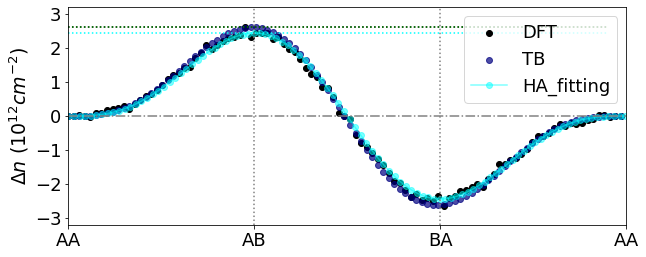

In [3]:
xx=np.loadtxt('slidy')
dft=np.loadtxt('dft_pz') #0 2(b1,b2) 1 3(n1,n2)
tb=np.loadtxt('tb_cdd') #B1 N1 B2 N2
size=18
plt.figure(figsize=(10,4))

dft_cdd=(dft[:,0]+dft[:,1]-dft[:,2]-dft[:,3])/area
tb_cdd=(2*tb[:,0]+2*tb[:,1]-2*tb[:,2]-2*tb[:,3])/area

plt.scatter(xx,2*dft_cdd/10e12,label='DFT',c='black')
plt.scatter(xx,tb_cdd/10e12,label='TB',c='navy',alpha=0.7)
# plt.scatter(dyv,-(cdd_N+cdd_B)/10e12,label='HA_fitting',c='firebrick',alpha=0.8)
plt.plot(dyv,-(hann+habb)/10e12,'o-',label='HA_fitting',c='cyan',alpha=0.5)

plt.ylabel('$\Delta n$ ($10^{12}$$cm^{-2}$)',fontsize=19)
plt.xticks([])
plt.yticks(fontsize=16)
plt.xlim(0,np.max(xx))
ss=0.0000
ym=3.2
# # plt.ylim(np.min(tb_cdd)-ss,np.max(tb_cdd)+ss)
plt.hlines(0,0,100,linestyles='dashdot',colors='grey')
plt.vlines(a/np.sqrt(3),-ym,ym,linestyles='dotted',colors='grey')
plt.vlines(2*a/np.sqrt(3),-ym,ym,linestyles='dotted',colors='grey')

# plt.vlines(2*a/np.sqrt(3),np.min(tb_cdd)-ss,np.max(tb_cdd)+ss,linestyles='dotted',colors='grey')
stack=(0,a/np.sqrt(3),2*a/np.sqrt(3),3*a/np.sqrt(3))
plt.xticks(stack, ('AA','AB','BA','AA'),fontsize=size)
plt.hlines(2.615,0,4.2,linestyles='dotted',colors='black')
plt.hlines(2.622,0,4.2,linestyles='dotted',colors='green')
plt.hlines(2.44,0,4.2,linestyles='dotted',colors='cyan')

plt.ylim(-ym,ym)
# plt.scatter(a/np.sqrt(3),2.036,marker='*',s=222,color='grey')
# plt.scatter(a/np.sqrt(3),2.67,marker='*',s=222,color='grey')
# plt.text(0,1.77,'TB',c='navy',fontsize=13)
# plt.text(-0.4,2.4,'HA-Fitting',c='firebrick',fontsize=13)
plt.legend(fontsize=18)
plt.yticks(fontsize=18)
# plt.savefig('density')
plt.savefig('pz_4atoms')
# print(np.max((cdd_N+cdd_B)/10e12))
print(np.max(tb_cdd/10e12),np.max(2*dft_cdd/10e12),np.max((hann+habb)/10e12))
# print(np.argmax(tb_cdd),np.argmin(tb_cdd))
# print(tb[33])
# print(xx[33])
a = 2.4795
T = a*np.array([[1,0],[-0.5,np.sqrt(3)/2]])
#slidy=a*np.sqrt(3)/20
#slid=slidy*33
# 0,0+1.4172246, 3.261,'bA')
# 0, (T[0]/3+2*T[1]/3)[1]+1.4172246, 3.261,'bB')
# 0, 0, 0,'tA')# B position in top layer 00000
# 0, (T[0]/3+2*T[1]/3)[1], 0,'tB')#N in top layer 1111

# print((T[0]/3+2*T[1]/3)[1]+1.4172246)

2.6153236481370508 2.622430305326499 2.440860781300385


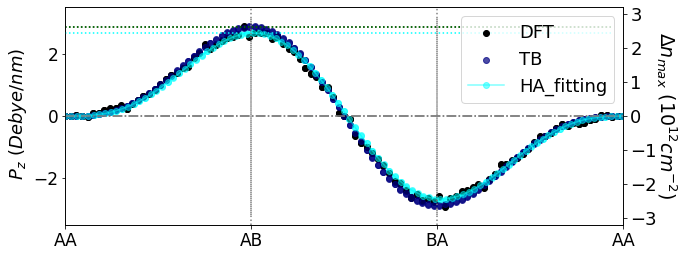

In [4]:
xx=np.loadtxt('slidy')
dft=np.loadtxt('dft_pz') #0 2(b1,b2) 1 3(n1,n2)
tb=np.loadtxt('tb_cdd') #B1 N1 B2 N2
size=18
fig,ax1=plt.subplots(figsize=(10,4))

dft_cdd=(dft[:,0]+dft[:,1]-dft[:,2]-dft[:,3])/area
tb_cdd=(2*tb[:,0]+2*tb[:,1]-2*tb[:,2]-2*tb[:,3])/area

ax1.scatter(xx,2*dft_cdd/10e12*1.11265,label='DFT',c='black')
ax1.set_ylabel('$\\ P_{z}$ ($Debye/nm$)',fontsize=18)
ax1.scatter(xx,tb_cdd/10e12*1.11265,label='TB',c='navy',alpha=0.7)
ax1.plot(dyv,-(hann+habb)/10e12*1.11265,'o-',label='HA_fitting',c='cyan',alpha=0.5)
ax1.hlines(0,0,100,linestyles='dashdot',colors='grey')
ax1.vlines(a/np.sqrt(3),-ym,ym,linestyles='dotted',colors='grey')
ax1.vlines(2*a/np.sqrt(3),-ym,ym,linestyles='dotted',colors='grey')
ax1.tick_params(axis='y',labelsize=17)
ax1.tick_params(axis='x',labelsize=17)
ax2=ax1.twinx()
ax2.scatter(xx,2*dft_cdd/10e12,label='DFT',c='black')
ax2.scatter(xx,tb_cdd/10e12,label='TB',c='navy',alpha=0.7)
# plt.scatter(dyv,-(cdd_N+cdd_B)/10e12,label='HA_fitting',c='firebrick',alpha=0.8)
ax2.plot(dyv,-(hann+habb)/10e12,'o-',label='HA_fitting',c='cyan',alpha=0.5)
ax2.set_ylabel('$\Delta n_{max}$ ($10^{12}$$cm^{-2}$)',fontsize=19,rotation=-90,labelpad=22)
# ax2.tick_params([])
ax2.tick_params(axis='y',labelsize=15)
ax2.tick_params(axis='x',labelsize=17)

plt.xlim(0,np.max(xx))
ss=0.0000
ym=3.2
# # plt.ylim(np.min(tb_cdd)-ss,np.max(tb_cdd)+ss)
ax2.hlines(0,0,100,linestyles='dashdot',colors='grey')
ax2.vlines(a/np.sqrt(3),-ym,ym,linestyles='dotted',colors='grey')
ax2.vlines(2*a/np.sqrt(3),-ym,ym,linestyles='dotted',colors='grey')

# plt.vlines(2*a/np.sqrt(3),np.min(tb_cdd)-ss,np.max(tb_cdd)+ss,linestyles='dotted',colors='grey')
stack=(0,a/np.sqrt(3),2*a/np.sqrt(3),3*a/np.sqrt(3))
# ax2.tick_params(stack, ('AA','AB','BA','AA'),fontsize=size)
ax2.hlines(2.615,0,4.2,linestyles='dotted',colors='black')
ax2.hlines(2.622,0,4.2,linestyles='dotted',colors='green')
ax2.hlines(2.44,0,4.2,linestyles='dotted',colors='cyan')
ax2.set_ylim(-ym,ym)
# plt.scatter(a/np.sqrt(3),2.036,marker='*',s=222,color='grey')
# plt.scatter(a/np.sqrt(3),2.67,marker='*',s=222,color='grey')
# plt.text(0,1.77,'TB',c='navy',fontsize=13)
# plt.text(-0.4,2.4,'HA-Fitting',c='firebrick',fontsize=13)
plt.legend(fontsize=18)
plt.yticks(fontsize=18)
plt.xticks(stack, ('AA','AB','BA','AA'),fontsize=22)
plt.savefig('pz_4atoms_2',dpi=300)
# print(np.max((cdd_N+cdd_B)/10e12))
print(np.max(tb_cdd/10e12),np.max(2*dft_cdd/10e12),np.max((hann+habb)/10e12))
# print(np.argmax(tb_cdd),np.argmin(tb_cdd))
# print(tb[33])
# print(xx[33])
a = 2.4795
T = a*np.array([[1,0],[-0.5,np.sqrt(3)/2]])
#slidy=a*np.sqrt(3)/20
#slid=slidy*33
# 0,0+1.4172246, 3.261,'bA')
# 0, (T[0]/3+2*T[1]/3)[1]+1.4172246, 3.261,'bB')
# 0, 0, 0,'tA')# B position in top layer 00000
# 0, (T[0]/3+2*T[1]/3)[1], 0,'tB')#N in top layer 1111

# print((T[0]/3+2*T[1]/3)[1]+1.4172246)